In [1]:
import os
import sys

os.chdir('..')
sys.path.append('src')

In [26]:
from utilsOptuna import remove_study_from_storage

remove_study_from_storage('sqlite:///optuna/optuna_DL_exercise.db', 'MDL_fcnn_shallow_metadata1')

Study 'MDL_fcnn_shallow_metadata1' not found


In [2]:
from utilsOptuna import info_studies_from_storage

storage = 'sqlite:///optuna/optuna_DL_exercise.db'
print(f"Storage: {storage}")
info_studies_from_storage(storage)

Storage: sqlite:///optuna/optuna_DL_exercise.db


,study_name,best_score,description
0,MDL_fcnn_pca_embeddings1,0.643243,FCNN with Progressive Compression Architecture...
1,MDL_resnet18_pretrain_images1,0.800000,ResNet18 pretrained parameters
2,MDL_resnet18_layer4_images1,0.851064,ResNet18 layer4 parameters optimization
3,MDL_mmodal3_pre_img1_meta1_emb1,0.878261,Multimodal: ResNet18 pre + fcnn_pca + metadata
4,MDL_mmodal3_layer4_img1_meta1_emb1,0.848739,Multimodal: ResNet18 layer4 + fcnn_pca + metadata
5,MML_logreg_metadata1,0.796076,Logistic Regression
6,MML_randomforest_metadata1,0.807312,Random Forest
7,MML_xgboost_metadata1,0.803216,XGBoost
8,MDL_fcnn_shallow_metadata1,0.790378,Shallow FCNN using metadata


In [ ]:
# TODO Save trial.user_attr range of parameters
# TODO For neuronal network visualizate by epoch
# TODO Summary protocol

In [3]:
import optuna

storage = 'sqlite:///optuna/optuna_DL_exercise.db'
study_name = 'MDL_mmodal3_pre_img1_meta1_emb1'
study = optuna.load_study(
    study_name = study_name,
    storage = storage
)
print(f'Loading {study.study_name} study...')
print(study.user_attrs['comments'])
# TODO Summary protocol
# dataset
# read data function
# preprocessing
# processing
# Architecture/Model
study.user_attrs['config_file']

Loading MDL_mmodal3_pre_img1_meta1_emb1 study...
Multimodal: ResNet18 pre + fcnn_pca + metadata


'optuna/file_config/MDL_mmodal3_pre_img1_meta1_emb1.pkl'

In [4]:
from utilsOptuna import info_runs_from_study
# TODO if all trials have been prunned. Show also run
# get info for runs of a study
print(f"Study: {study.study_name}")
# TODO add datatime_complete
#study.get_trials()[0]
info_runs_from_study(study.trials)

Study: MDL_mmodal3_pre_img1_meta1_emb1


,run,num_trials,completed_trials,best_score
0,base_name,10,9,0.868085
1,extension1_run,5,3,0.878261


In [5]:
info_runs_from_study(study.trials, extended=True)
# TODO search space for each run
# TODO function to show search space for each run. Not in table but text/json format
# Study:...
# base_run 9/10
# datatime  start   end
# best score 0.868
# optimized hyperparameters
#   batch_size
#       low
#       high
#       ...  
#   lr
#       low
#       high
#       ...
# fixed hyperparameters
#

,run,num_trials,completed_trials,best_score,datetime_start,datetime_complete,dist_batch_size,dist_lr
0,base_name,10,9,0.868085,2025-10-29 18:47:36,2025-10-29 19:46:21,"IntDistribution(high=5, log=False, low=2, step=1)","FloatDistribution(high=0.5, log=True, low=0.00..."
1,extension1_run,5,3,0.878261,2025-10-30 18:12:25,2025-10-30 18:42:59,"IntDistribution(high=6, log=False, low=4, step=1)","FloatDistribution(high=0.01, log=True, low=0.0..."


In [6]:
from utilsOptuna import optuna_results

# output for best_trial
print(f"Storage: {storage}")
print(f"Study: {study_name}")
optuna_results(study)

Storage: sqlite:///optuna/optuna_DL_exercise.db
Study: MDL_mmodal3_pre_img1_meta1_emb1
Best trial:
  Value:  0.8782608695652174
  Params: 
    batch_size:	5.00000
    lr:	0.00342


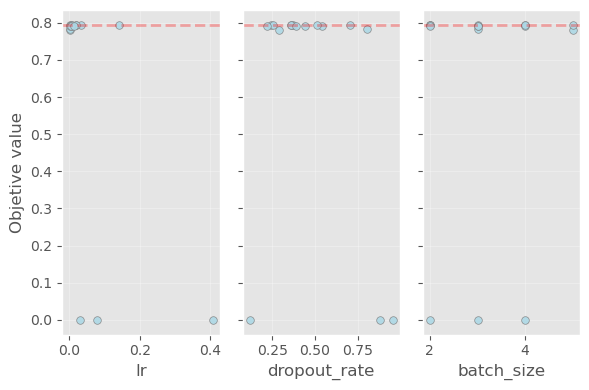

In [20]:
from utilsOptuna import plot_slice

# TODO Custom plot_slice adapt log variables to axis scale
# TODO Custom plot_slice select highest trials
# TODO Remove lowest values equals to zero
# TODO Select run
plot_slice(study) # Slice plot param vs objetiveValue

/tmp/ipykernel_38831/1507289557.py:5: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'lr']) # 2D contour plot


<Axes: title={'center': 'Contour Plot'}, xlabel='batch_size', ylabel='lr'>

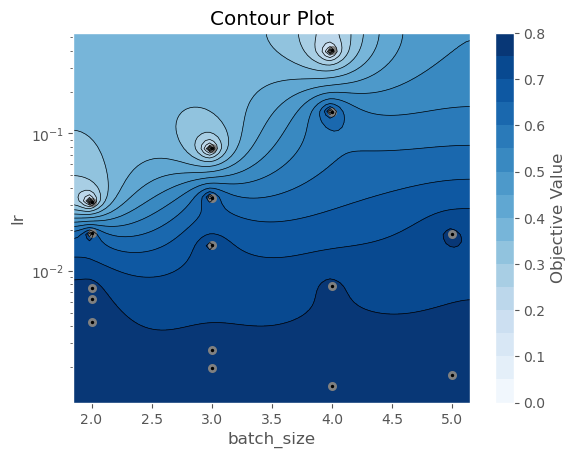

In [ ]:
import optuna

# TODO plot optimized hyperparameters
# TODO Make custom plot_contour. Highlight best result.
# TODO Show pruned trials
optuna.visualization.matplotlib.plot_contour(study, params=['batch_size', 'lr']) # 2D contour plot


In [16]:
# TODO Plot loss and score by epoch

In [ ]:
# TODO How to calculate importance features. Is strange? Most importance to max_depth and n_estimators?
#optuna.visualization.matplotlib.plot_param_importances(study,evaluator=optuna.importance.FanovaImportanceEvaluator())